<a href="https://colab.research.google.com/github/S1h2l/color-image-processing-/blob/main/create_gauss_spectrum_question_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

cmf = pd.read_csv("cb_cmm.csv", delim_whitespace=True, header=None)
cmf.columns = ['x_bar', 'y_bar', 'z_bar']

wavelengths = np.arange(400, 701, 5)


x_bar = cmf['x_bar'].values
y_bar = cmf['y_bar'].values
z_bar = cmf['z_bar'].values

print("Wavelengths:", wavelengths[:5], "…", wavelengths[-5:])
print("x_bar sample:", x_bar[:5])
print("y_bar sample:", y_bar[:5])
print("z_bar sample:", z_bar[:5])

Wavelengths: [400 405 410 415 420] … [680 685 690 695 700]
x_bar sample: [0.178338   0.17714286 0.17539863 0.17317404 0.17064419]
y_bar sample: [0.01867414 0.01836735 0.01822323 0.01785934 0.01785714]
z_bar sample: [0.80298786 0.8044898  0.80637813 0.80896662 0.81149866]


/tmp/ipython-input-2227505967.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  cmf = pd.read_csv("cb_cmm.csv", delim_whitespace=True, header=None)


In [ ]:
def create_gauss_spectrum(center, bandwidth, energy):
    w = bandwidth / 6
    spectrum = energy / (np.sqrt(2 * np.pi) * w) * \
               np.exp(-(wavelengths - center)**2 / (2 * w**2))
    return spectrum

In [ ]:
def spect2rgb(spect):
    X = np.sum(spect * x_bar)
    Y = np.sum(spect * y_bar)
    Z = np.sum(spect * z_bar)

    XYZ = np.array([X, Y, Z])

    M = np.array([[3.2406, -1.5372, -0.4986],
                  [-0.9689, 1.8758, 0.0415],
                  [0.0557, -0.2040, 1.0570]])

    RGB = M @ XYZ

    RGB = np.clip(RGB, 0, None)

    def gamma_correct(c):
        c = np.where(c <= 0.0031308, 12.92*c, 1.055*c**(1/2.4) - 0.055)
        return c

    RGB = gamma_correct(RGB)

    RGB = np.clip(RGB, 0, 1)

    return RGB


In [ ]:
spect1 = create_gauss_spectrum(center=450, bandwidth=30, energy=1.0)
spect2 = create_gauss_spectrum(center=550, bandwidth=50, energy=1.0)
spect3 = create_gauss_spectrum(center=650, bandwidth=40, energy=1.0)

rgb1 = spect2rgb(spect1)
rgb2 = spect2rgb(spect2)
rgb3 = spect2rgb(spect3)

print("RGB1 (Blue-ish):", rgb1)
print("RGB2 (Green-ish):", rgb2)
print("RGB3 (Red-ish):", rgb3)


RGB1 (Blue-ish): [0.06134275 0.         0.45131973]
RGB2 (Green-ish): [0.17082275 0.45695014 0.        ]
RGB3 (Red-ish): [0.64494278 0.         0.        ]


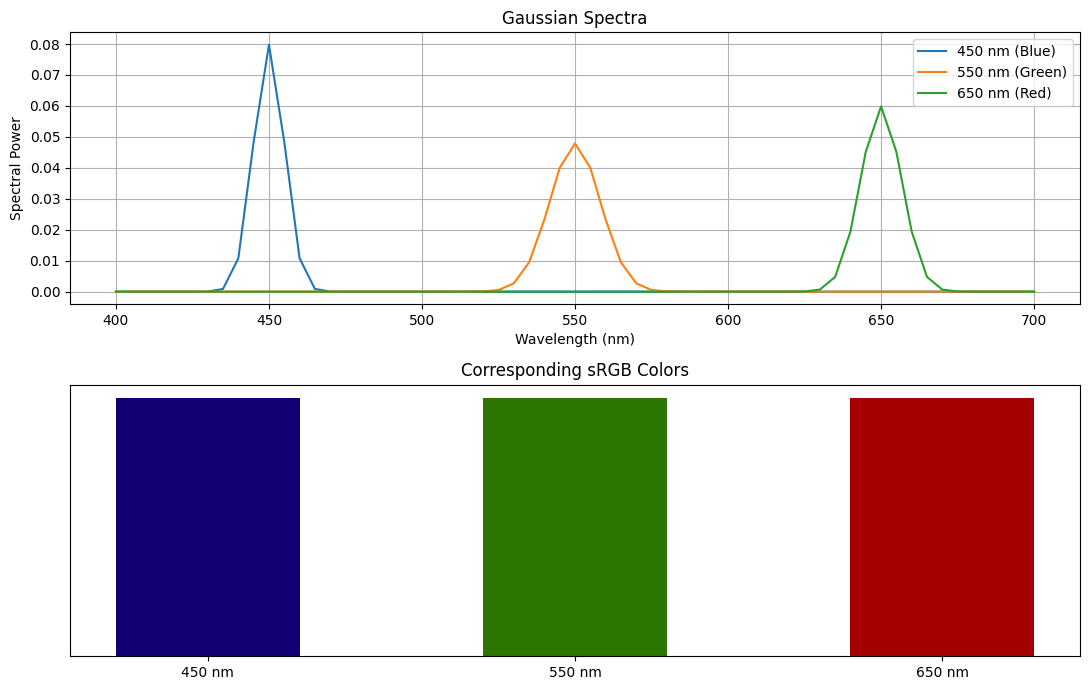

In [ ]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 1, figsize=(11, 7))

axs[0].plot(wavelengths, spect1, label="450 nm (Blue)")
axs[0].plot(wavelengths, spect2, label="550 nm (Green)")
axs[0].plot(wavelengths, spect3, label="650 nm (Red)")
axs[0].set_xlabel("Wavelength (nm)")
axs[0].set_ylabel("Spectral Power")
axs[0].set_title("Gaussian Spectra")
axs[0].legend()
axs[0].grid(True)

colors = [rgb1, rgb2, rgb3]
axs[1].bar([0, 1, 2], [1, 1, 1], color=colors, width=0.5)
axs[1].set_xticks([0, 1, 2])
axs[1].set_xticklabels(["450 nm", "550 nm", "650 nm"])
axs[1].set_yticks([])
axs[1].set_title("Corresponding sRGB Colors")

plt.tight_layout()
plt.show()
